# **Replication of Table 3**：
### $\mu$-adjusted method
- **实验（模拟）结论**：
    - 引入后悔后，资产的期望、偏度与与 ex-post 最优基准的协动性成为决定其吸引力的关键；
    - **收益后悔** *放大均值和偏度*的作用、*削弱方差*的作用；
    - **偏好后悔** *放大风险厌恶*并使结果更接近 Markowitz。
---
- **实证结论**：
    - 后悔（尤其 **收益后悔**）会导致**显著不同的最优权重和事前收益分布**；
    - 同时 **收益后悔** 的最优组合往往呈现更高均值、波动与偏度但更差的尾部表现；
    - **偏好后悔** 效果较温和。

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.optimize import minimize
import math
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

## **一. 实验 / 模拟结果**

两种后悔度量：**return-regret**（以事后收益最高的资产为基准）和**preference-regret**（以事后偏好值最高的可行组合为基准）。

- 在MVO分析下，后悔可以等价为（A）调整协方差矩阵，或（B）调整预期收益向量（并在 preference-regret 下把风险厌恶系数放大为 $(1+α)γ$）。
- 后悔模型仍能用 μ–σ 优化求解：只要把协方差或均值做“后悔调整”即可（因此保留 Markowitz 的可解性）。（Property 1、Property 2）。

#### **资产特征影响权重的改变方向 —— 与 Markowitz 的差别**

- 期望收益（mean）：在 return-regret 下，期望收益比 Markowitz 更重要（对权重更敏感）；在 preference-regret 下，因风险厌恶被放大，期望收益相对影响反而变小。直觉：高均值资产更易成为 ex-post 最优，从而降低其相对后悔风险。
- 波动率（std / variance）：后悔模型（尤其 return-regret）中，资产的方差作用被相对弱化——variance 的影响比 Markowitz 小；在某些情形下，return-regret 下权重对 σ 的变化几乎不敏感（两资产同分布时权重仍 1/2）。直觉：后悔风险更多由“成为 ex-post 最优的概率”决定。
- 偏度（skewness）：在 Markowitz 中偏度不进入二阶模型，但在后悔模型中（尤其 return-regret）正偏度显著增加资产吸引力（高偏度→更高与 ex-post 最优的协方差→降低后悔风险→权重上升）。数值上偏度从 −1→+1 会把权重从 ≈0.35 拉到 ≈0.65（两资产示例）。
- 相关性（correlation）：相关性仍然使资产多样化价值发生变化，但在纯后悔模型下相关性效应较 Markowitz 弱；即后悔会一定程度缓和 correlation 的影响。

- 极端情况与参数依赖
    - α（后悔权重）与 γ（风险厌恶）交互：若没有卖空限制，任何中间 α 的最优权重是 Markowitz（α=0）和纯后悔（α=1）权重的加权平均（Property 3），
    - 所以两极情况足以理解中间情形。preference-regret 会把 γ 放大为 (1+α)γ，从而增强对方差的厌恶。
---

- **对最优组合的总体影响**
    - **在收益后悔下，最优组合往往期望收益更高、方差更高、偏度更高（也有更差的尾部风险），即更倾向押注高均值/高偏度资产，但承担更高波动与极端损失风险**
    - **偏好后悔的结果通常更接近 Markowitz（或介于两者之间），具体取决于 $\gamma$**。

以上为文章 Section 3 的比较静态与模拟结论汇总；具体图表：Fig.1–6 展示 mean / std / skew / corr / γ 的影响规律。

In [33]:
np.random.seed(123)

# ---- 参数（与论文 base scenario 对齐） ----
mu = np.array([0.10, 0.10])        # 期望（年化或单位一致）
sigma = np.array([0.25, 0.25])     # 标准差
rho = 0.5
gamma = 3.0
alpha = 1.0                        # 纯 regret case (alpha=1)；可改为 0.5, 0
n_sims = 2000_000                   # 试验用 200k；论文用了 2,000,000

# 构造协方差矩阵
cov = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]], [rho*sigma[0]*sigma[1], sigma[1]**2]])

# 生成多元正态模拟（每次模拟是两资产的 realized returns）
R = np.random.multivariate_normal(mean=mu, cov=cov, size=n_sims)  # shape (n_sims, 2)

# ---- return-regret: Z_ret_{j,t} = R_{j,t} - alpha * R_max_t ----
R_max = R.max(axis=1)                         
Z_ret = R - alpha * R_max[:, None]            # 广播，shape (n_sims,2)

# 估计 regret-adjusted 均值与协方差
mu_ra_ret = Z_ret.mean(axis=0)
cov_ra_ret = np.cov(Z_ret, rowvar=False, bias=False)

# ---- preference-regret:
# π(R_j, sigma_j^2) ~ R_j - gamma * sigma_j^2  （使用已知 sigma_j^2）
# π_max_t = max_j [ R_{j,t} - gamma * sigma_j^2 ]
pi_vals = R - gamma * (sigma**2)[None, :]     # shape (n_sims,2)
pi_max = pi_vals.max(axis=1)
# Z_pref_{j,t} = R_{j,t} - alpha * pi_max_t - alpha * gamma * sigma_j^2
Z_pref = R - alpha * pi_max[:, None] - alpha * gamma * (sigma**2)[None, :]

mu_ra_pref = Z_pref.mean(axis=0)
cov_ra_pref = np.cov(Z_pref, rowvar=False, bias=False)

# ---- 求解带预算约束的 μ-σ 最优权重（闭式，无短售约束）
def mean_variance_weights(mu_vec, cov_mat, gamma):
    # 目标： max_w w^T mu - gamma * w^T cov w ; subject to 1^T w = 1
    # 解法（见论文/附录）： w = (1/(2γ)) Σ^{-1} μ  - (λ/(2γ)) Σ^{-1} 1
    # λ 通过预算约束求解： λ = (1^T Σ^{-1} μ - 2γ) / (1^T Σ^{-1} 1)
    invS = np.linalg.inv(cov_mat)
    A = invS.dot(mu_vec)
    B = invS.dot(np.ones_like(mu_vec))
    denom = np.ones_like(mu_vec).dot(B)
    lam = (np.ones_like(mu_vec).dot(A) - 2*gamma) / denom
    w = (A - lam * B) / (2*gamma)
    return w

w_markowitz = mean_variance_weights(mu, cov, gamma)
w_ret = mean_variance_weights(mu_ra_ret, cov_ra_ret, gamma)
w_pref = mean_variance_weights(mu_ra_pref, cov_ra_pref, gamma)

# 输出对照
print("Markowitz weights:", w_markowitz)
print("Pure return-regret weights:", w_ret)
print("Pure preference-regret weights:", w_pref)

Markowitz weights: [0.5 0.5]
Pure return-regret weights: [0.4992371 0.5007629]
Pure preference-regret weights: [0.4992371 0.5007629]


### **Figure 1_Part A**

- **期望收益**：
- 在 **收益后悔** 下，期望收益比 Markowitz 更重要（对权重更敏感）；
- 在 **偏好后悔** 下，因风险厌恶被放大，期望收益相对影响反而变小。
- 直觉：高均值资产更易成为 ex-post 最优，从而降低其相对后悔风险。

sigma = [0.25, 0.25]: 两个资产的标准差均为25%（基础情景）  
rho = 0.5: 相关系数0.5  
cov_base: 根据公式 

    Σ = [[σ₁²,     ρσ₁σ₂],
         [ρσ₁σ₂,   σ₂²]]    构建协方差矩阵，代入 σ₁=σ₂=0.25, ρ=0.5。 得到：
    Σ = [[0.0625, 0.03125],
         [0.03125, 0.0625]]
gamma = 3: 风险厌恶系数  
alpha = 1: 纯后悔情形（只关注后悔，不关注绝对收益）  
mu2 = 0.1: 资产2的固定预期收益10%  
mu1_grid: 资产1的预期收益从0%到20%变化，生成25个点  

根据论文Property 2公式(9): 
$$\hat{\mu}^{ret} = \mu + 2\alpha\gamma Cov(R, R_{max})$$
$$\hat{\mu}^{pref}= \mu + 2\alpha\gamma Cov(R, \pi_{max})$$

cov_R_Rmax[0] = Cov(R₁, R_max)  
cov_R_Rmax[1] = Cov(R₂, R_max)

**这个协方差衡量了资产与最佳表现的"同步性"**：
- 高协方差 → 当该资产表现好时，整体市场也好 → 后悔风险低
- 低协方差 → 该资产可能"错过"市场最佳表现 → 后悔风险高

In [2]:
rho = 0.5
n_sims = 2000000
sigma = np.array([0.25, 0.25])
cov_base = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]],[rho*sigma[0]*sigma[1], sigma[1]**2]])
cov_base

array([[0.0625 , 0.03125],
       [0.03125, 0.0625 ]])

In [3]:
invS = np.linalg.inv(cov_base)
invS

array([[ 21.33333333, -10.66666667],
       [-10.66666667,  21.33333333]])

In [4]:
mu1_grid = np.linspace(0, 0.2, 25)
mu2 = 0.1
for i, mu1 in enumerate(mu1_grid): # 遍历不同的资产1预期收益
    mu = np.array([mu1, mu2])
    R = np.random.multivariate_normal(mean=mu, cov=cov_base, size=n_sims)  # 对每个mu1值，生成二元正态收益数据
    R_max = R.max(axis=1)
    # 计算每个资产收益与最佳资产收益的协方差
    cov_R_Rmax = np.array([np.cov(R[:,0], R_max, bias=False)[0,1], np.cov(R[:,1], R_max, bias=False)[0,1]])
cov_R_Rmax

array([0.05175579, 0.04205698])

In [5]:
# 按 Property 2 实现 mu 的调整来融入后悔效应，同时保持原始协方差矩阵不变。
np.random.seed(1114)
sigma = np.array([0.25, 0.25])
rho = 0.5
cov_base = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]],[rho*sigma[0]*sigma[1], sigma[1]**2]])
gamma = 3
alpha = 1
mu2 = 0.1
# 当资产1的预期收益从0%变化到20%时，最优权重如何变化
mu1_grid = np.linspace(0, 0.2, 25)
n_grid = len(mu1_grid)
n_sims = 2000000

w_mk = np.zeros(n_grid)
w_ret = np.zeros(n_grid)
w_pref = np.zeros(n_grid)

In [6]:
# 遍历不同的资产1预期收益
for i, mu1 in enumerate(mu1_grid): 
    mu = np.array([mu1, mu2])
    R = np.random.multivariate_normal(mean=mu, cov=cov_base, size=n_sims)  # 对每个mu1值，生成二元正态收益数据
    R_max = R.max(axis=1)
    # 计算每个资产收益与最佳资产收益的协方差
    cov_R_Rmax = np.array([np.cov(R[:,0], R_max, bias=False)[0,1], np.cov(R[:,1], R_max, bias=False)[0,1]]) # 提取协方差矩阵中第0行、第1列的元素
    
    # (sigma**2)[None, :] 将形状从 (2,) 变为 (1, 2)
    pi_values = R - gamma * (sigma**2)[None, :] # sigma**2 是一个形状为 (2,) 的一维数组  R 是一个形状为 (n_sims, 2) 的二维数组；
    pi_max = pi_values.max(axis=1)
    cov_R_pimax = np.array([np.cov(R[:,0], pi_max, bias=False)[0,1], np.cov(R[:,1], pi_max, bias=False)[0,1]])

    # 传统 Markowitz
    invS = np.linalg.inv(cov_base)                         
    A = invS.dot(mu)                                       
    B = invS.dot(np.ones_like(mu))                         
    denom = np.ones_like(mu).dot(B)                        
    lam = (np.ones_like(mu).dot(A) - 2*gamma) / denom      
    w = (A - lam * B) / (2*gamma)
    w_mk[i] = w[0]    # 存储的是在不同μ₁值下，资产1的最优权重

    # 收益后悔 仍使用原始收益(未调整）的协方差矩阵的逆。
    mu_ra_ret = mu + 2*alpha*gamma*cov_R_Rmax              # Property 2 公式9                    
    A_ret = invS.dot(mu_ra_ret)
    lam_ret = (np.ones_like(mu).dot(A_ret) - 2*gamma) / denom
    w_r = (A_ret - lam_ret * B) / (2*gamma)
    w_ret[i] = w_r[0]

    # 偏好后悔 仍使用原始收益(未调整）的协方差矩阵的逆。
    mu_ra_pref = mu + 2*alpha*gamma*cov_R_pimax
    gamma_pref = gamma * (1 + alpha)                       # 在偏好后悔下，投资者对风险更加厌恶                    
    A_pref = invS.dot(mu_ra_pref)
    lam_pref = (np.ones_like(mu).dot(A_pref) - 2*gamma_pref) / denom
    w_p = (A_pref - lam_pref * B) / (2*gamma_pref)
    w_pref[i] = w_p[0]

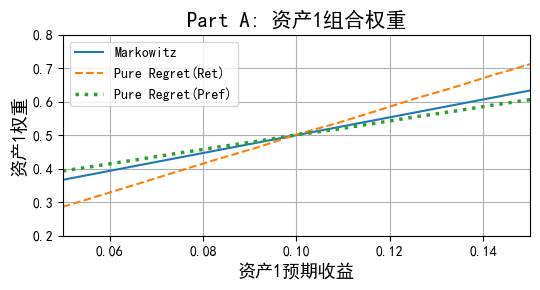

In [7]:
plt.figure(figsize=(5.5, 3))
plt.plot(mu1_grid, w_mk,   linestyle='-',   label='Markowitz')
plt.plot(mu1_grid, w_ret,  linestyle='--',  label='Pure Regret(Ret)')
plt.plot(mu1_grid, w_pref, linestyle=':', linewidth=2.5, label='Pure Regret(Pref)')
plt.xlim(0.05, 0.15)
plt.ylim(0.2, 0.8)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))
plt.xlabel('资产1预期收益', fontsize=13, fontweight='heavy')
plt.ylabel('资产1权重',     fontsize=13, fontweight='heavy')
plt.title('Part A: 资产1组合权重', fontsize=15, fontweight='heavy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

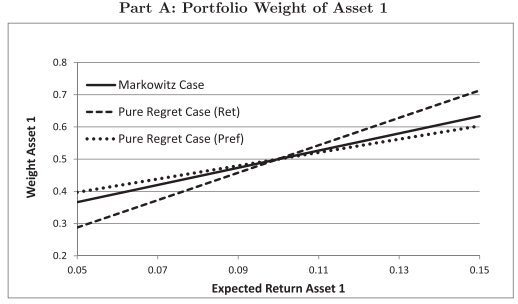

期望收益：在 **收益后悔** 下，期望收益比 Markowitz 更重要（对权重更敏感）；在 **偏好后悔** 下，因风险厌恶被放大，期望收益相对影响反而变小。  
直觉：高均值资产更易成为 ex-post 最优，从而降低其相对后悔风险。

### **Part B**

In [8]:
np.random.seed(1114)
sigma = np.array([0.25, 0.25])
rho = 0.5
cov_base = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]],[rho*sigma[0]*sigma[1], sigma[1]**2]])

mu2 = 0.10
mu1_grid = np.linspace(0.00, 0.20, 25)
n_sims = 2000000 

# 用来记录 Part B 的两个协方差序列
cov_R1_Rmax = np.zeros(len(mu1_grid))
cov_R2_Rmax = np.zeros(len(mu1_grid))

# 逐点循环
for i, mu1 in enumerate(mu1_grid):
    mu = np.array([mu1, mu2])  # 当前期望
    R = np.random.multivariate_normal(mean=mu, cov=cov_base, size=n_sims)  # 模拟 R（shape: n_sims x 2）
    R_max = R.max(axis=1)
    # 计算两个协方差： Cov(R1, R_max), Cov(R2, R_max)
    cov_R1_Rmax[i] = np.cov(R[:,0], R_max, bias=False)[1,0]
    cov_R2_Rmax[i] = np.cov(R[:,1], R_max, bias=False)[0,1]

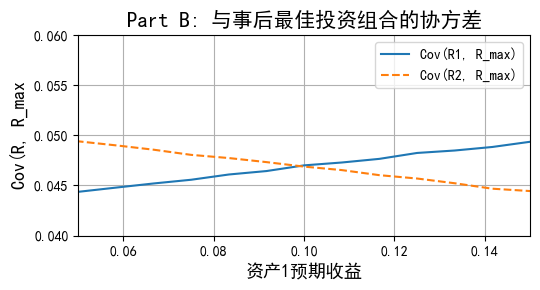

In [9]:
# 绘图（Part B）
plt.figure(figsize=(5.5,3))
plt.plot(mu1_grid, cov_R1_Rmax, linestyle='-', label='Cov(R1, R_max)')
plt.plot(mu1_grid, cov_R2_Rmax, linestyle='--', label='Cov(R2, R_max)')
plt.xlim(0.05, 0.15)
plt.ylim(0.04, 0.06)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.005))
plt.xlabel('资产1预期收益', fontsize=13, fontweight='heavy')
plt.ylabel('Cov(R, R_max', fontsize=13, fontweight='heavy')
plt.title('Part B: 与事后最佳投资组合的协方差', fontsize=15, fontweight='heavy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

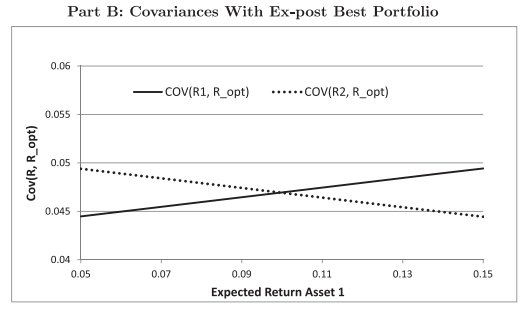

资产1的协方差 $\text{Cov}(R_1, R_{\max})$：随预期收益增加而上升

资产2的协方差 $\text{Cov}(R_2, R_{\max})$：随资产1预期收益增加而下降

当资产1的预期收益 $\mu_1$ 增加时，它在任何给定时期成为最佳资产的概率 $P(R_1 = R_{\max})$ 增加  
当 $R_1 = R_{\max}$ 时，$R_1$ 与 $R_{\max}$ 完全正相关  
因此，$\text{Cov}(R_1, R_{\max})$ 反映了"资产1成为最佳资产的可能性"  

当资产1的预期收益增加时，资产2成为最佳资产的概率 $P(R_2 = R_{\max})$ 下降  
即使资产2的收益很高，但资产1的收益可能更高（因为 $\mu_1$ 增加了）  
因此资产2与 $R_{\max}$ 的联动性减弱  

### **Figure 2_Part A**


In [10]:
np.random.seed(1114)
mu = np.array([0.10, 0.10])   # 两资产相同期望收益
sigma2 = 0.25                 # asset2 固定的标准差
rho = 0.5
gamma = 3.0
alpha = 1.0

# sigma1 网格（资产1 标准差从 0.05 到 0.50）
sigma1_grid = np.linspace(0.05, 0.50, 25)
n_grid = len(sigma1_grid)
n_sims = 2000000

w_mk = np.zeros(n_grid)
w_ret = np.zeros(n_grid)
w_pref = np.zeros(n_grid)

# 逐点循环
for i, s1 in enumerate(sigma1_grid):
    cov = np.array([[s1**2, rho*s1*sigma2], [rho*s1*sigma2, sigma2**2]])  # 当前的协方差矩阵（随 s1 变化）
    R = np.random.multivariate_normal(mean=mu, cov=cov, size=n_sims)
    R_max = R.max(axis=1)
    # 计算 Cov(R_j, R_max) 的向量
    cov_R_Rmax = np.array([np.cov(R[:,0], R_max, bias=False)[0,1], np.cov(R[:,1], R_max, bias=False)[0,1]])
    pi_vals = R - gamma * np.array([s1**2, sigma2**2])[None, :]
    pi_max = pi_vals.max(axis=1)
    cov_R_pimax = np.array([np.cov(R[:,0], pi_max, bias=False)[0,1], np.cov(R[:,1], pi_max, bias=False)[0,1]])

    # Markowitz 权重
    invS = np.linalg.inv(cov)
    A = invS.dot(mu)
    B = invS.dot(np.ones_like(mu))
    lam = (np.ones_like(mu).dot(A) - 2*gamma) / (np.ones_like(mu).dot(B))
    w = (A - lam * B) / (2*gamma)
    w_mk[i] = w[0]

    # 收益后悔
    mu_ra_ret = mu + 2*alpha*gamma*cov_R_Rmax
    A_ret = invS.dot(mu_ra_ret)
    lam_ret = (np.ones_like(mu).dot(A_ret) - 2*gamma) / (np.ones_like(mu).dot(B))
    w_r = (A_ret - lam_ret * B) / (2*gamma)
    w_ret[i] = w_r[0]

    # 偏好后悔
    mu_ra_pref = mu + 2*alpha*gamma*cov_R_pimax
    gamma_pref = gamma * (1 + alpha)
    A_pref = invS.dot(mu_ra_pref)
    lam_pref = (np.ones_like(mu).dot(A_pref) - 2*gamma_pref) / (np.ones_like(mu).dot(B))
    w_p = (A_pref - lam_pref * B) / (2*gamma_pref)
    w_pref[i] = w_p[0]

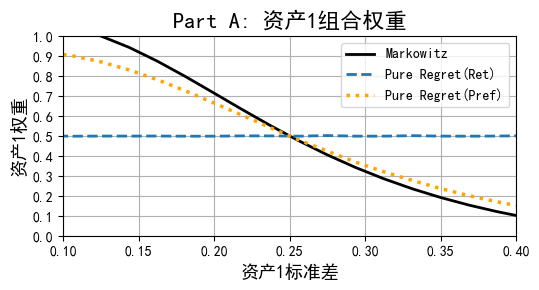

In [11]:
# 绘图（Part A）
plt.figure(figsize=(5.5,3))
plt.plot(sigma1_grid, w_mk, color='black', linewidth=2, label='Markowitz')
plt.plot(sigma1_grid, w_ret, linestyle='--', linewidth=2, label='Pure Regret(Ret)')
plt.plot(sigma1_grid, w_pref, color='orange', linestyle=':', linewidth=2.5, label='Pure Regret(Pref)')
plt.xlim(0.1, 0.4)
plt.ylim(0, 1)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))
plt.xlabel('资产1标准差', fontsize=13, fontweight='heavy')
plt.ylabel('资产1权重', fontsize=13, fontweight='heavy')
plt.title('Part A: 资产1组合权重', fontsize=16, fontweight='heavy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

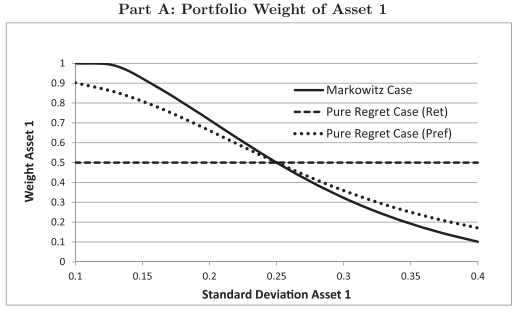

**波动率（std / variance）**：
- 后悔模型（尤其 **收益后悔**）中，资产的方差作用被相对弱化—— variance 的影响比 Markowitz 小；
- 在某些情形下，**收益后悔** 下权重对 标准差 的变化几乎不敏感（两资产同分布时权重仍 1/2）。
- 直觉：后悔风险更多由“成为事后最优的概率”决定。
- 波动率增加可能增加 $\text{Cov}(R_i, R_{\max})$
- 这抵消了波动率增加的负面效应
- 结果：权重对波动率变化不敏感

### **Part B**

In [12]:
np.random.seed(1115)
mu = np.array([0.10, 0.10])
sigma2 = 0.25
rho = 0.5
gamma = 3.0
sigma1_grid = np.linspace(0.05, 0.50, 25)
n_sims = 2000000

cov_R1_Rmax = np.zeros(len(sigma1_grid))
cov_R2_Rmax = np.zeros(len(sigma1_grid))
cov_R1_pimax = np.zeros(len(sigma1_grid))
cov_R2_pimax = np.zeros(len(sigma1_grid))

# 逐点计算
for i, s1 in enumerate(sigma1_grid):
    cov = np.array([[s1**2, rho*s1*sigma2],[rho*s1*sigma2, sigma2**2]])
    
    R = np.random.multivariate_normal(mean=mu, cov=cov, size=n_sims)
    R_max = R.max(axis=1)
    cov_R1_Rmax[i] = np.cov(R[:,0], R_max, bias=False)[0,1]
    cov_R2_Rmax[i] = np.cov(R[:,1], R_max, bias=False)[0,1]
    
    pi_vals = R - gamma * np.array([s1**2, sigma2**2])[None, :]
    pi_max = pi_vals.max(axis=1)
    cov_R1_pimax[i] = np.cov(R[:,0], pi_max, bias=False)[0,1]
    cov_R2_pimax[i] = np.cov(R[:,1], pi_max, bias=False)[0,1]

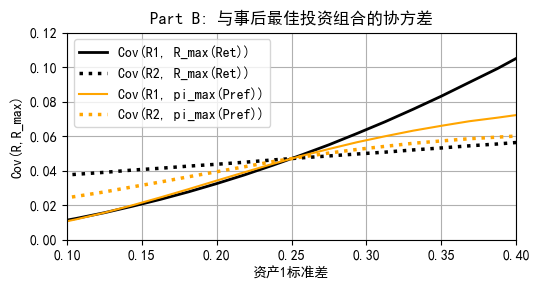

In [13]:
# 绘图 
plt.figure(figsize=(5.5,3))
plt.plot(sigma1_grid, cov_R1_Rmax, color='black', linewidth=2, label='Cov(R1, R_max(Ret))')
plt.plot(sigma1_grid, cov_R2_Rmax, color='black', linestyle=':', linewidth=2.5, label='Cov(R2, R_max(Ret))')
plt.plot(sigma1_grid, cov_R1_pimax, color='orange', linestyle='-', linewidth=1.5, label='Cov(R1, pi_max(Pref))')
plt.plot(sigma1_grid, cov_R2_pimax, color='orange', linestyle=':', linewidth=2.5, label='Cov(R2, pi_max(Pref))')
plt.xlim(0.1, 0.4)
plt.ylim(0, 0.12)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.05))

plt.xlabel('资产1标准差')
plt.ylabel('Cov(R,R_max)')
plt.title('Part B: 与事后最佳投资组合的协方差')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

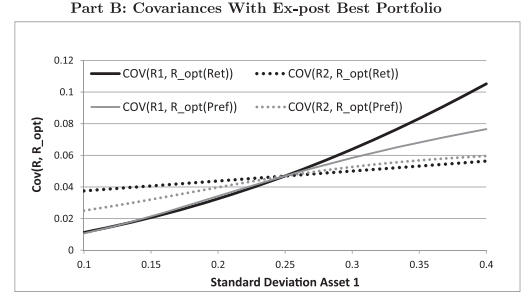

### **Fig 3**

In [14]:
np.random.seed(1115)

# 预期收益不再相同
mu = np.array([0.05, 0.10])   # 和 Fig.2 最大区别：mu1=5%, mu2=10%
sigma2 = 0.25                 # asset2 固定波动率
rho = 0.5
gamma = 3.0
alpha = 1.0
# sigma1 网格（资产1的标准差）
sigma1_grid = np.linspace(0.05, 0.50, 25)
n_sims = 2000000
w_mk = np.zeros(len(sigma1_grid))
w_ret = np.zeros(len(sigma1_grid))
w_pref = np.zeros(len(sigma1_grid))

# 循环逐点计算
for i, s1 in enumerate(sigma1_grid):
    cov = np.array([[s1**2, rho*s1*sigma2], [rho*s1*sigma2, sigma2**2]])
    
    R = np.random.multivariate_normal(mean=mu, cov=cov, size=n_sims)
    R_max = R.max(axis=1)
    cov_R_Rmax = np.array([np.cov(R[:,0], R_max, bias=False)[0,1], np.cov(R[:,1], R_max, bias=False)[0,1]])
    
    pi_vals = R - gamma * np.array([s1**2, sigma2**2])[None, :]
    pi_max = pi_vals.max(axis=1)
    cov_R_pimax = np.array([np.cov(R[:,0], pi_max, bias=False)[0,1], np.cov(R[:,1], pi_max, bias=False)[0,1]])

    # Markowitz
    invS = np.linalg.inv(cov)
    A = invS.dot(mu)
    B = invS.dot(np.ones_like(mu))
    lam = (np.ones_like(mu).dot(A) - 2*gamma) / (np.ones_like(mu).dot(B))
    w = (A - lam * B) / (2*gamma)
    w_mk[i] = w[0]

    # 收益后悔
    mu_ra_ret = mu + 2*alpha*gamma*cov_R_Rmax
    A_ret = invS.dot(mu_ra_ret)
    lam_ret = (np.ones_like(mu).dot(A_ret) - 2*gamma) / (np.ones_like(mu).dot(B))
    w_r = (A_ret - lam_ret * B) / (2*gamma)
    w_ret[i] = w_r[0]

    # 偏好后悔
    mu_ra_pref = mu + 2*alpha*gamma*cov_R_pimax
    gamma_pref = gamma * (1 + alpha)
    A_pref = invS.dot(mu_ra_pref)
    lam_pref = (np.ones_like(mu).dot(A_pref) - 2*gamma_pref) / (np.ones_like(mu).dot(B))
    w_p = (A_pref - lam_pref * B) / (2*gamma_pref)
    w_pref[i] = w_p[0]

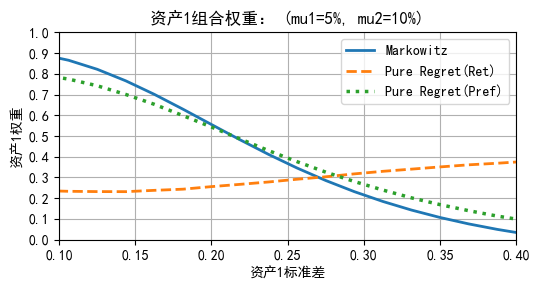

In [15]:
# 绘图
plt.figure(figsize=(5.5, 3))
plt.plot(sigma1_grid, w_mk,  linewidth=2, label='Markowitz')
plt.plot(sigma1_grid, w_ret, linestyle='--', linewidth=2, label='Pure Regret(Ret)')
plt.plot(sigma1_grid, w_pref, linestyle=':',  linewidth=2.5, label='Pure Regret(Pref)')

plt.xlim(0.1, 0.4)
plt.ylim(0, 1)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.05))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))
plt.xlabel('资产1标准差')
plt.ylabel('资产1权重')
plt.title('资产1组合权重： (mu1=5%, mu2=10%)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

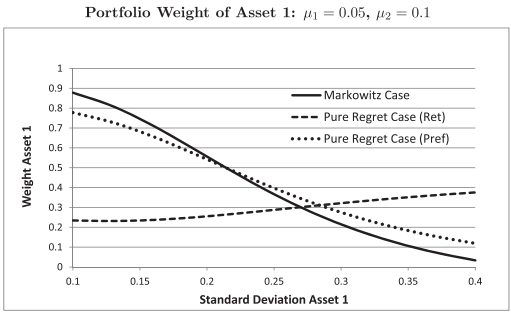

### **Fig 4**

**偏度（skewness）**：
- 在 Markowitz 中偏度不进入二阶模型，但在后悔模型中（尤其 **收益后悔**）正偏度显著增加资产吸引力
    - （高偏度 → 更高与事后最优的协方差 → 降低后悔风险 → 权重上升）。
- 数值上偏度从 $−1 → +1$ 会把权重从 ≈0.35 拉到 ≈0.65（两资产示例）。

In [16]:
np.random.seed(1116)
mu = np.array([0.10, 0.10])      # 两资产收益相同
sigma = np.array([0.25, 0.25])   # 两资产标准差相同
rho = 0.5
gamma = 3.0
alpha = 1.0

# 偏度设置（-1 到 +1）
skew_grid = np.linspace(-1.0, 1.0, 25)
n_sims = 2000000
w_mk   = np.zeros(len(skew_grid))
w_ret  = np.zeros(len(skew_grid))
w_pref = np.zeros(len(skew_grid))

# 协方差矩阵固定（资产2 正态；资产1 方差不变，仅改变偏度）
cov_base = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]],[rho*sigma[0]*sigma[1], sigma[1]**2]])

for i, skew in enumerate(skew_grid):
    # 生成相关正态 Z1, Z2
    L = np.linalg.cholesky(np.array([[1, rho],[rho, 1]]))
    Z = np.random.randn(n_sims, 2).dot(L.T)
    Z1 = Z[:,0]
    Z2 = Z[:,1]

    # 生成 Gram–Charlier 偏度随机变量
    c = 0.75
    X = Z1 + c * skew * (Z1**2 - 1)
    X_std = (X - np.mean(X)) / np.std(X)   # 标准化以确保 Var(X)=1
    R1 = mu[0] + sigma[0] * X_std          # 转换为资产 1 的收益
    R2 = mu[1] + sigma[1] * Z2             # 资产 2 正态
    R = np.column_stack([R1, R2])
    R_max = R.max(axis=1)                  # 计算 R_max 与 pi_max

    cov_R_Rmax = np.array([np.cov(R[:,0], R_max, bias=False)[0,1], np.cov(R[:,1], R_max, bias=False)[0,1]])
    pi_vals = R - gamma * (sigma**2)[None,:]
    pi_max = pi_vals.max(axis=1)
    cov_R_pimax = np.array([np.cov(R[:,0], pi_max, bias=False)[0,1],np.cov(R[:,1], pi_max, bias=False)[0,1]])

    invS = np.linalg.inv(cov_base)
    B = invS.dot(np.ones_like(mu))

    # Markowitz
    A = invS.dot(mu)
    lam = (np.ones_like(mu).dot(A) - 2*gamma) / (np.ones_like(mu).dot(B))
    w = (A - lam * B) / (2*gamma)
    w_mk[i] = w[0]

    # 收益后悔
    mu_ra_ret = mu + 2*alpha*gamma*cov_R_Rmax
    A_ret = invS.dot(mu_ra_ret)
    lam_ret = (np.ones_like(mu).dot(A_ret) - 2*gamma) / (np.ones_like(mu).dot(B))
    w_r = (A_ret - lam_ret * B) / (2*gamma)
    w_ret[i] = w_r[0]

    # 偏好后悔
    mu_ra_pref = mu + 2*alpha*gamma*cov_R_pimax
    gamma_pref = gamma * (1 + alpha)
    A_pref = invS.dot(mu_ra_pref)
    lam_pref = (np.ones_like(mu).dot(A_pref) - 2*gamma_pref) / (np.ones_like(mu).dot(B))
    w_p = (A_pref - lam_pref * B) / (2*gamma_pref)
    w_pref[i] = w_p[0]

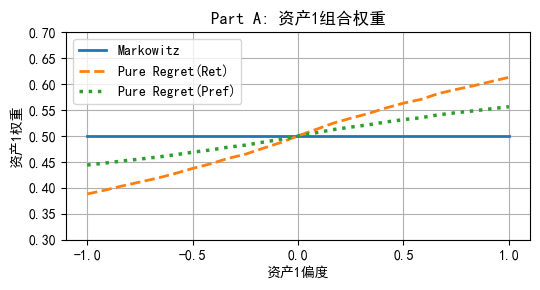

In [17]:
plt.figure(figsize=(5.5, 3))
plt.plot(skew_grid, w_mk,  linewidth=2, label='Markowitz')
plt.plot(skew_grid, w_ret, linestyle='--', linewidth=2, label='Pure Regret(Ret)')
plt.plot(skew_grid, w_pref, linestyle=':',  linewidth=2.5, label='Pure Regret(Pref)')

plt.ylim(0.3, 0.7)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.05))
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))

plt.xlabel('资产1偏度')
plt.ylabel('资产1权重')
plt.title('Part A: 资产1组合权重')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

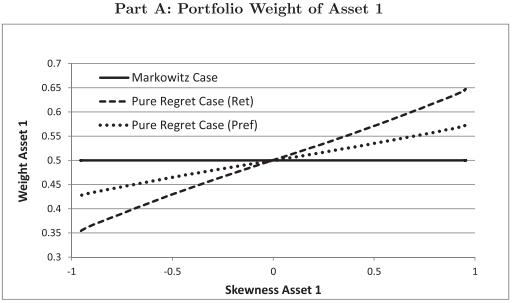

### **Fig 5**

**相关性（correlation）**：  
- 相关性仍然使资产多样化价值发生变化，但在纯后悔模型下相关性效应较 Markowitz 弱；
- 即后悔会一定程度缓和 correlation 的影响。

In [18]:
np.random.seed(1117)
n_assets = 3
mu = np.full(n_assets, 0.10)    # 全部资产均值 10%
sigma = np.full(n_assets, 0.25) # 全部资产波动 25%
rho_other = 0.5                 # 其他资产之间的相关系数（除 asset1 外）
gamma = 3.0
alpha = 1.0

# rho 网格：改变资产1与其他每个资产的相关性
rho_grid = np.linspace(0.0, 0.95, 25)  # 从 0 到 0.95，25 点
n_grid = len(rho_grid)
n_sims = 2000000

# 资产1的权重
w_mk = np.zeros(n_grid)
w_ret = np.zeros(n_grid)
w_pref = np.zeros(n_grid)

# 逐点循环
for i, rho_var in enumerate(rho_grid):
    # 构造相关矩阵 Corr（3x3）
    Corr = np.full((n_assets, n_assets), rho_other)  # 先填充 0.5
    np.fill_diagonal(Corr, 1.0)                      # 对角为 1
    Corr[0,1] = rho_var # 把资产1与其余资产的相关性改为 rho_var
    Corr[1,0] = rho_var
    Corr[0,2] = rho_var
    Corr[2,0] = rho_var # Corr[1,2] 与 Corr[2,1] 保持 rho_other (0.5)
    
    Sigma = np.zeros((n_assets, n_assets)) # 根据 Corr 与 sigma 构造协方差矩阵 Sigma
    for a in range(n_assets):
        for b in range(n_assets):
            Sigma[a,b] = sigma[a] * sigma[b] * Corr[a,b]
    R = np.random.multivariate_normal(mean=mu, cov=Sigma, size=n_sims)
    R_max = R.max(axis=1)  # 计算事后最优资产收益 R_max （每一期在 n_assets 中取最大）

    # 计算向量 Cov(R_j, R_max)
    cov_R_Rmax = np.zeros(n_assets)
    for j in range(n_assets):
        cov_R_Rmax[j] = np.cov(R[:, j], R_max, bias=False)[0,1]

    # 计算 pi = R - gamma*sigma_j^2，并取 pi_max
    pi_vals = R - gamma * (sigma**2)[None, :]
    pi_max = pi_vals.max(axis=1)

    # 计算 Cov(R_j, pi_max)
    cov_R_pimax = np.zeros(n_assets)
    for j in range(n_assets):
        cov_R_pimax[j] = np.cov(R[:, j], pi_max, bias=False)[0,1]

    # 准备线性代数项（用于闭式解）
    invS = np.linalg.inv(Sigma)      # 论文在 Property2 中用原始 Sigma
    one_vec = np.ones(n_assets)
    B = invS.dot(one_vec)

    # Markowitz: A = invS * mu，求 lambda 与 w
    A = invS.dot(mu)
    lam = (one_vec.dot(A) - 2*gamma) / (one_vec.dot(B))
    w = (A - lam * B) / (2*gamma)
    w_mk[i] = w[0]   # asset1 权重

    # 收益后悔: mu_ra = mu + 2*alpha*gamma*cov_R_Rmax，gamma 不变
    mu_ra_ret = mu + 2*alpha*gamma*cov_R_Rmax
    A_ret = invS.dot(mu_ra_ret)
    lam_ret = (one_vec.dot(A_ret) - 2*gamma) / (one_vec.dot(B))
    w_ret_vec = (A_ret - lam_ret * B) / (2*gamma)
    w_ret[i] = w_ret_vec[0]

    # 偏好后悔: mu_ra = mu + 2*alpha*gamma*cov_R_pimax，gamma_pref = gamma*(1+alpha)
    mu_ra_pref = mu + 2*alpha*gamma*cov_R_pimax
    gamma_pref = gamma * (1 + alpha)
    A_pref = invS.dot(mu_ra_pref)
    lam_pref = (one_vec.dot(A_pref) - 2*gamma_pref) / (one_vec.dot(B))
    w_pref_vec = (A_pref - lam_pref * B) / (2*gamma_pref)
    w_pref[i] = w_pref_vec[0]

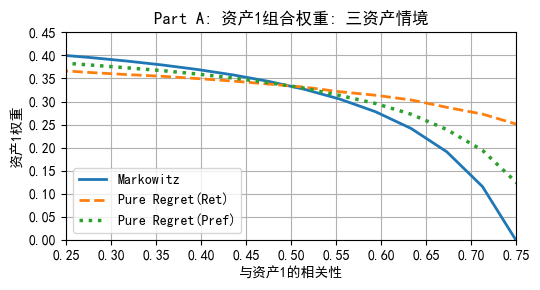

In [19]:
# 绘图（Fig.5 Part A）
plt.figure(figsize=(5.5,3))
plt.plot(rho_grid, w_mk, label='Markowitz', linewidth=2)
plt.plot(rho_grid, w_ret, linestyle='--', label='Pure Regret(Ret)', linewidth=2)
plt.plot(rho_grid, w_pref, linestyle=':', label='Pure Regret(Pref)', linewidth=2.5)

plt.ylim(0, 0.45)
plt.xlim(0.25, 0.75)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.05))
plt.gca().xaxis.set_major_locator(MultipleLocator(0.05))

plt.xlabel('与资产1的相关性')
plt.ylabel('资产1权重')
plt.title('Part A: 资产1组合权重: 三资产情境')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

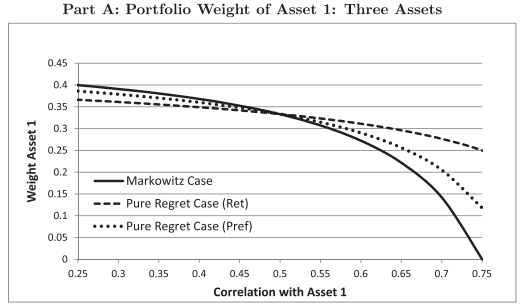

### **Fig 6**

**极端情况与参数依赖**
- $\alpha$（后悔权重）与 $\gamma$（风险厌恶）交互：
    - 若没有卖空限制，任何中间 α 的最优权重是 Markowitz（α=0）和纯后悔（α=1）权重的加权平均（Property 3），所以两极情况足以理解中间情形。
- **偏好后悔** 会把 $\gamma$ 放大为 $(1+\alpha)\gamma$，从而增强对方差的厌恶。

In [20]:
np.random.seed(1118)

mu = np.array([0.05, 0.15])
sigma = np.array([0.10, 0.40])
rho = 0.5
alpha = 1.0
cov = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]],[rho*sigma[0]*sigma[1], sigma[1]**2]])
gamma_grid = np.linspace(0.0, 10.0, 25)
n_sims = 2000000

w_mk = np.zeros(len(gamma_grid))
w_ret = np.zeros(len(gamma_grid))
w_pref = np.zeros(len(gamma_grid))

# 预先计算 invS, B（Sigma 不随 gamma 变）
invS = np.linalg.inv(cov)
one = np.ones(2)
B = invS.dot(one)

for idx, gamma in enumerate(gamma_grid):
    # 解析边界：gamma==0
    if gamma == 0.0:
        best = np.argmax(mu)
        w = np.zeros(2); w[best] = 1.0
        w_mk[idx] = w_ret[idx] = w_pref[idx] = w[0]
        continue

    R = np.random.multivariate_normal(mean=mu, cov=cov, size=n_sims)
    R_max = R.max(axis=1)
    cov_R_Rmax = np.array([np.cov(R[:,0], R_max, bias=False)[0,1], np.cov(R[:,1], R_max, bias=False)[0,1]])

    pi = R - gamma * (sigma**2)[None,:]
    pi_max = pi.max(axis=1)
    cov_R_pimax = np.array([np.cov(R[:,0], pi_max, bias=False)[0,1], np.cov(R[:,1], pi_max, bias=False)[0,1]])

    # Markowitz
    A = invS.dot(mu)
    lam = (one.dot(A) - 2*gamma) / (one.dot(B))
    w = (A - lam * B) / (2*gamma)
    w_mk[idx] = w[0]

    # 收益后悔
    mu_ra_ret = mu + 2*alpha*gamma*cov_R_Rmax
    A_ret = invS.dot(mu_ra_ret)
    lam_ret = (one.dot(A_ret) - 2*gamma) / (one.dot(B))
    w_r = (A_ret - lam_ret * B) / (2*gamma)
    w_ret[idx] = w_r[0]

    # 偏好后悔
    mu_ra_pref = mu + 2*alpha*gamma*cov_R_pimax
    gamma_pref = gamma * (1 + alpha)
    A_pref = invS.dot(mu_ra_pref)
    lam_pref = (one.dot(A_pref) - 2*gamma_pref) / (one.dot(B))
    w_p = (A_pref - lam_pref * B) / (2*gamma_pref)
    w_pref[idx] = w_p[0]

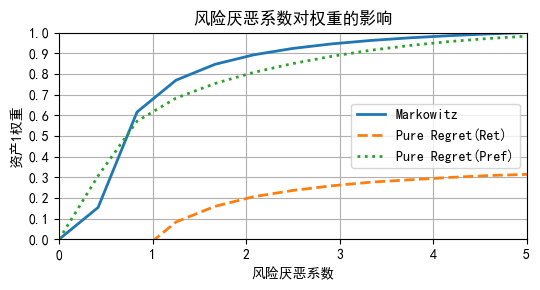

In [21]:
plt.figure(figsize=(5.5, 3))
plt.plot(gamma_grid, w_mk,  linewidth=2, label='Markowitz')
plt.plot(gamma_grid, w_ret, linestyle='--', linewidth=2, label='Pure Regret(Ret)')
plt.plot(gamma_grid, w_pref, linestyle=':',  linewidth=2, label='Pure Regret(Pref)')

plt.ylim(0, 1)
plt.xlim(0, 5)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))

plt.xlabel('风险厌恶系数')
plt.ylabel('资产1权重')
plt.title('风险厌恶系数对权重的影响')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

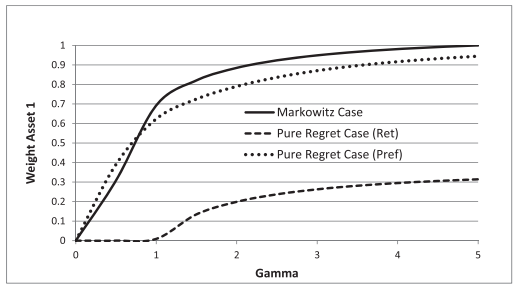

### **Fig 7**

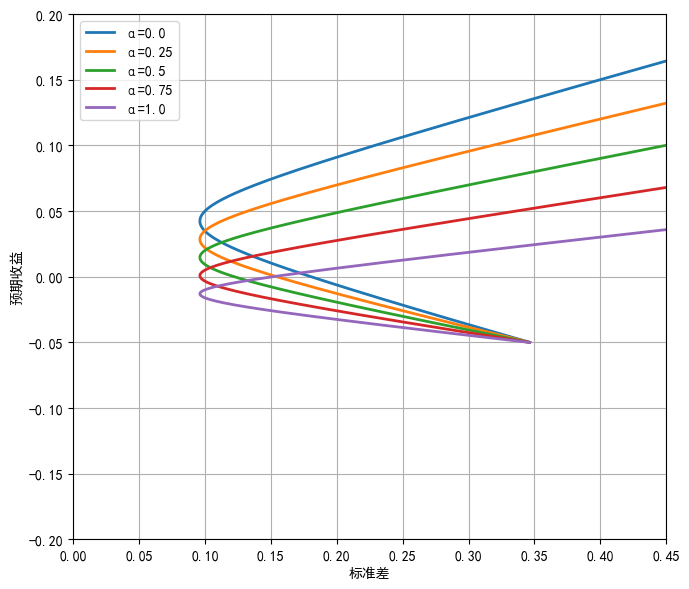

In [29]:
np.random.seed(202402)
mu = np.array([0.05, 0.15])
sigma = np.array([0.10, 0.40])
rho = 0.5
gamma = 3.0
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]    # 与原文一致
n_sims = 2000000                      # 可提高到1e6进一步平滑

Sigma = np.array([[sigma[0]**2, rho*sigma[0]*sigma[1]], [rho*sigma[0]*sigma[1], sigma[1]**2]])

# 模拟收益序列
R = np.random.multivariate_normal(mu, Sigma, n_sims)

# j* = argmax(mu - gamma*sigma²) 并取 R_opt = 单资产最优收益序列
phi = mu - gamma*(sigma**2)
j_star = int(np.argmax(phi))
R_opt = R[:, j_star]

cov_vec = np.array([np.cov(R[:,0], R_opt)[0,1], np.cov(R[:,1], R_opt)[0,1]])

# 横轴sigma, 纵轴mu^ra
w1 = np.linspace(-1.0,2.0,400)

plt.figure(figsize=(7, 6))
for alpha in alphas:
    mu_adj = mu - 2*alpha*gamma*cov_vec
    stds=[]
    rets=[]
    for w in w1:
        wv = np.array([w,1-w])
        stds.append(np.sqrt(wv@Sigma@wv))
        rets.append(wv@mu_adj)
    plt.plot(stds,rets,label=f"α={alpha}",linewidth=2)

plt.xlim(0, 0.45)
plt.xticks(np.arange(0, 0.46, 0.05))
plt.ylim(-0.2, 0.2)
plt.yticks(np.arange(-0.2, 0.21, 0.05))

plt.xlabel('标准差')
plt.ylabel('预期收益')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

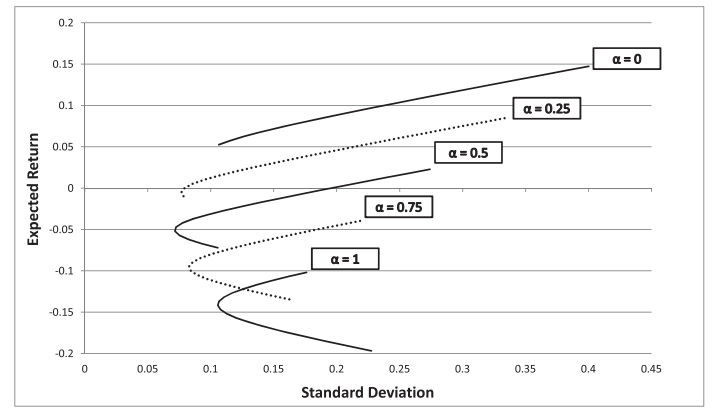

## **二. 实证结果**

**主要实证结论如下**：

**后悔导致最优权重发生显著变化（数量级很大，尤其是收益后悔）**

**Styles （表 3）：类似模式出现——在 return-regret 框架下，具有高预期收益或高偏度的基金被强烈超配；preference-regret 的权重变动通常较温和，更接近 Markowitz，但仍能出现明显差异（表中多个基金权重从 0→显著正值或反之）**。

后悔调整会改变最优组合的事前收益分布

在 return-regret 下，最优组合的事前均值↑、标准差↑、偏度↑，但同时极端亏损（Expected Shortfall）变差（更低）；换言之，return-regret 最优组合的夏普可能下降但期望更高，尾部风险上升。preference-regret 的分布特征通常更接近 Markowitz。

In [118]:
# 导入CRSP数据
mom = pd.read_csv('E:/Replications/2025_Fall/Baule_2019_Markowitz with regret/F-F_Momentum_Factor_daily.csv')
ff3 = pd.read_csv('E:/Replications/2025_Fall/Baule_2019_Markowitz with regret/F-F_Research_Data_Factors_daily.csv')
ff3["date"] = pd.to_datetime(ff3["date"], format="%Y%m%d")
mom["date"] = pd.to_datetime(mom["date"], format="%Y%m%d")

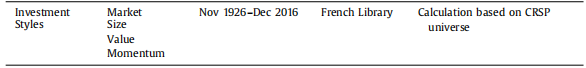

In [53]:
mom.head()

,date,MOM
0,1926-11-03,0.54
1,1926-11-04,-0.51
2,1926-11-05,1.17
3,1926-11-06,-0.03
4,1926-11-08,-0.02


In [54]:
ff3.head()

,date,Mkt-RF,SMB,HML,RF
0,1926-07-01,0.09,-0.25,-0.27,0.01
1,1926-07-02,0.45,-0.33,-0.06,0.01
2,1926-07-06,0.17,0.30,-0.39,0.01
3,1926-07-07,0.09,-0.58,0.02,0.01
4,1926-07-08,0.22,-0.38,0.19,0.01


In [119]:
ff4 = pd.merge(ff3, mom, on="date", how="inner")
start_date = "1926-11-01"
end_date   = "2016-12-31"
ff4 = ff4[(ff4["date"] >= start_date) & (ff4["date"] <= end_date)]
ff4

,date,Mkt-RF,SMB,HML,RF,MOM
0,1926-11-03,0.20,-0.20,-0.33,0.01,0.54
1,1926-11-04,0.59,-0.12,0.65,0.01,-0.51
2,1926-11-05,0.07,-0.11,0.26,0.01,1.17
3,1926-11-06,0.15,-0.29,0.05,0.01,-0.03
4,1926-11-08,0.52,-0.12,0.18,0.01,-0.02
...,...,...,...,...,...,...
23783,2016-12-23,0.19,0.57,-0.50,0.00,-0.39
23784,2016-12-27,0.27,0.22,0.13,0.00,0.28
23785,2016-12-28,-0.87,-0.27,0.08,0.00,-0.13
23786,2016-12-29,-0.04,0.15,-0.33,0.00,0.09


In [120]:
# 选择用于 Table 3 的四个风格列（已为超额收益）
assets = ['Mkt-RF', 'SMB', 'HML', 'MOM']
df = ff4.copy()

# 确保按日期排序且去掉含 NaN 的行
df = df.sort_values('date').reset_index(drop=True)
df_assets = df[assets].astype(float).dropna()
df_assets = df_assets/100
df_assets

,Mkt-RF,SMB,HML,MOM
0,0.0020,-0.0020,-0.0033,0.0054
1,0.0059,-0.0012,0.0065,-0.0051
2,0.0007,-0.0011,0.0026,0.0117
3,0.0015,-0.0029,0.0005,-0.0003
4,0.0052,-0.0012,0.0018,-0.0002
...,...,...,...,...
23783,0.0019,0.0057,-0.0050,-0.0039
23784,0.0027,0.0022,0.0013,0.0028
23785,-0.0087,-0.0027,0.0008,-0.0013
23786,-0.0004,0.0015,-0.0033,0.0009


### **在面板A和B中，所有呈现数值的偏差均以括号形式标注在各数值下方，括号内数值表示与均值的偏离程度**。

In [60]:
# 计算每个资产的基本统计量
annual_factor = 252
assets = df_assets.columns
stats_calculations = [('Mean Return', df_assets.mean() * annual_factor), 
                      ('Std. Deviation', df_assets.std() * np.sqrt(annual_factor)),
                      ('Skewness', df_assets.skew())]

stats_data = []
index = []

for stat_name, values in stats_calculations:
    # 添加统计量行
    stats_data.append(values.round(4))
    index.append(stat_name)
    # 添加偏差行
    deviations = values - values.mean()
    stats_data.append(pd.Series([f"({dev:.4f})" for dev in deviations], index=assets))
    index.append('')

panel_a_stats = pd.DataFrame(stats_data, index=index, columns=assets)
panel_a_stats

,Mkt-RF,SMB,HML,MOM
Mean Return,0.0726,0.0136,0.0437,0.0659
,(0.0236),(-0.0353),(-0.0052),(0.0169)
Std. Deviation,0.1694,0.093,0.0933,0.1183
,(0.0509),(-0.0255),(-0.0252),(-0.0002)
Skewness,-0.125,-0.7604,0.7828,-1.6382
,(0.3102),(-0.3252),(1.2180),(-1.2030)


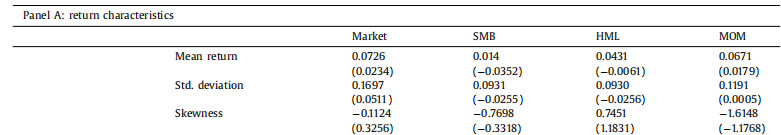

In [130]:
alpha = 1
gamma = 3
std_ret_adj = {}
covariances_ret = {}
regret_adjustment_mu = {}
cov = {'Mkt-RF': 0.0032,'SMB': -0.0009,'HML': 0.0002,'MOM': -0.0006}
df_asset = df_assets.copy()
df_assets_ret_adj = df_assets.copy()
df_asset['R_max'] = df_asset[['Mkt-RF', 'SMB', 'HML', 'MOM']].max(axis=1)

1. $Z_P^{ret} = R_P - \alpha R_{\max}$

2. 计算 $\text{Cov}(R_i, R_{\max})$ 并进行年化

3. $\hat{\mu}^{ret} = \mu + 2\alpha\gamma \cdot \text{Cov}(R, R_{\max})$

**理论基础**

根据论文Property 2，收益后悔模型可以通过调整期望收益来等价表示：  
原始优化问题：
$$\max_{\omega} \Pi(Z_P^{ret}) = E[Z_P^{ret}] - \gamma \cdot \text{Var}(Z_P^{ret})$$
$$\text{其中 } Z_P^{ret} = R_P - \alpha R_{\max}$$
等价表示（使用原始协方差矩阵）：
$$\max_{\omega} \omega^\top \hat{\mu}^{ret} - \gamma \cdot \omega^\top \Sigma \omega$$
$$\text{其中 } \hat{\mu}^{ret} = \mu + 2\alpha\gamma \cdot \text{Cov}(R, R_{\max})$$

**期望收益调整量的推导**

后悔调整收益的方差：
$$\begin{align*}
\text{Var}(Z_P^{ret}) &= \text{Var}(R_P - \alpha R_{\max}) \\
&= \omega^\top \Sigma \omega - 2\alpha \cdot \omega^\top \text{Cov}(R, R_{\max}) + \alpha^2 \text{Var}(R_{\max})
\end{align*}$$
目标函数重写：
$$\begin{align*}
\Pi(Z_P^{ret}) &= E[R_P] - \alpha E[R_{\max}] - \gamma [\omega^\top \Sigma \omega - 2\alpha \cdot \omega^\top \text{Cov}(R, R_{\max}) + \alpha^2 \text{Var}(R_{\max})] \\
&= \omega^\top \mu - \alpha E[R_{\max}] - \gamma \omega^\top \Sigma \omega + 2\alpha\gamma \cdot \omega^\top \text{Cov}(R, R_{\max}) - \gamma\alpha^2 \text{Var}(R_{\max}) \\
&= \omega^\top [\mu + 2\alpha\gamma \cdot \text{Cov}(R, R_{\max})] - \gamma \omega^\top \Sigma \omega - \text{常数项}
\end{align*}$$
常数项不影响优化，因此得到等价问题：
$$\hat{\mu}^{ret} = \mu + 2\alpha\gamma \cdot \text{Cov}(R, R_{\max})$$

Regret adjustment $\mu = 2\alpha\gamma \cdot \text{Cov}(R, R_{\max})$

In [131]:
for asset in assets:
    df_assets_ret_adj[f'{asset}_ret_adj'] = df_asset[asset] - alpha * df_asset['R_max']
    cov_daily = np.cov(df_asset[asset], df_asset['R_max'])[0, 1]
    cov_annual = cov_daily * 252  # 年化
    covariances_ret[asset] = cov_annual
    std_daily = df_assets_ret_adj[f'{asset}_ret_adj'].std()
    std_annual = std_daily * np.sqrt(252)  # 年化标准差
    std_ret_adj[asset] = std_annual
    adjustment = 2 * alpha * gamma * cov[asset]
    regret_adjustment_mu[asset] = adjustment #* covariances_ret[asset]


adj_values = [regret_adjustment_mu[asset] for asset in assets]
adj_mean = np.mean(adj_values)
adj_deviations = [val - adj_mean for val in adj_values]

std_values = [std_ret_adj[asset] for asset in assets]
std_mean = np.mean(std_values)
std_deviations = [val - std_mean for val in std_values]

In [132]:
data_dict = {}
for i, asset in enumerate(assets):
    data_dict[asset] = [f"{regret_adjustment_mu[asset]:.4f}", f"({adj_deviations[i]:.4f})",
                        f"{std_ret_adj[asset]:.4f}", f"({std_deviations[i]:.4f})"]

ret_regret_df = pd.DataFrame(data_dict)
ret_regret_df.index = ['Regret adjustment μ', '', 'Regret-adj. std. dev.', '']
ret_regret_df

,Mkt-RF,SMB,HML,MOM
Regret adjustment μ,0.0192,-0.0054,0.0012,-0.0036
,(0.0164),(-0.0083),(-0.0016),(-0.0065)
Regret-adj. std. dev.,0.1578,0.1453,0.1289,0.1585
,(0.0102),(-0.0023),(-0.0188),(0.0109)


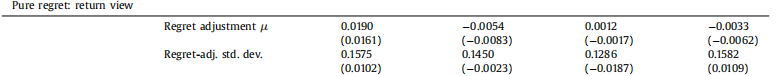

**Regret adjustment $\mu$**：  
- 反映资产因减少后悔风险而获得的"额外吸引力"
- 正值表示该资产与最佳资产联动性强，后悔风险低
- 负值表示该资产经常错过最佳机会，后悔风险高

**Regret-adj. std. dev.**：
- 衡量后悔调整后的总风险
- 包含传统风险和后悔风险

In [32]:
# 计算μ-σ情况 (γ=3) 下的Preference-regret
df_assets_pi = df_assets.copy()
variances_daily = {}
df_assets_pref_mu_sigma = df_assets.copy()
std_pref_adj = {}

for asset in assets:
    # 计算每个资产的方差（日度）
    variances_daily[asset] = df_assets[asset].var()
    # 计算每个时期的偏好值 π = R - γσ²
    df_assets_pi[f'pi_{asset}'] = df_assets[asset] - gamma * variances_daily[asset]
# 计算每个因子的π_max
df_assets_pi['pi_max'] = df_assets_pi[['pi_Mkt-RF', 'pi_SMB', 'pi_HML', 'pi_MOM']].max(axis=1)

# 计算每个资产与π_max的协方差 (用于μ调整)
cov_pref = {}
for asset in assets:
    cov_pref[asset] = np.cov(df_assets[asset], df_assets_pi['pi_max'])[0, 1]
    # 计算Preference-regret调整后收益 Z_pref = R - απ_max - αγσ²
    df_assets_pref_mu_sigma[f'Z_pref_{asset}'] = (df_assets[asset] - alpha * df_assets_pi['pi_max'] - alpha * gamma * variances_daily[asset])
    # 计算调整后收益的标准差
    std_pref_adj[asset] = df_assets_pref_mu_sigma[f'Z_pref_{asset}'].std()

In [114]:
annual_factor = 252
sqrt_annual_factor = np.sqrt(annual_factor)
# 年化协方差&标准差
cov_pref_mu_sigma = {asset: cov * annual_factor for asset, cov in cov_pref.items()}
std_pref_adj_mu_sigma = {asset: std * sqrt_annual_factor for asset, std in std_pref_adj.items()}

# 计算各统计量的平均值
avg_cov_pref_mu_sigma = np.mean(list(cov_pref_mu_sigma.values()))
avg_std_pref_mu_sigma = np.mean(list(std_pref_adj_mu_sigma.values()))

# 计算偏离值
deviations_cov_pref_mu_sigma = {asset: cov - avg_cov_pref_mu_sigma for asset, cov in cov_pref_mu_sigma.items()}
deviations_std_pref_mu_sigma = {asset: std - avg_std_pref_mu_sigma for asset, std in std_pref_adj_mu_sigma.items()}

In [115]:
data_dict = {}
for asset in assets:
    data_dict[asset] = [f"{cov_pref_mu_sigma[asset]:.4f}", f"({deviations_cov_pref_mu_sigma[asset]:.4f})",
                        f"{std_pref_adj_mu_sigma[asset]:.4f}", f"({deviations_std_pref_mu_sigma[asset]:.4f})"]

pref_mu_sigma_df = pd.DataFrame(data_dict)
pref_mu_sigma_df.index = ['Regret adjustment μ', '', 'Regret-adj. std. dev.', '']
pref_mu_sigma_df

,Mkt-RF,SMB,HML,MOM
Regret adjustment μ,0.0081,0.0001,0.0024,0.0008
,(0.0052),(-0.0027),(-0.0005),(-0.0021)
Regret-adj. std. dev.,0.1585,0.1448,0.1284,0.1582
,(0.0111),(-0.0027),(-0.0191),(0.0107)


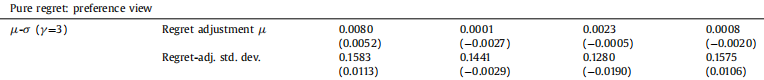

In [35]:
# 最小方差情况下偏好后悔模型的计算
def min_variance_pref_regret(df_assets, assets, alpha=1, gamma=3):
    cov_matrix_daily = df_assets[assets].cov()
    n_assets = len(assets)
    ones = np.ones(n_assets) # 最小方差组合优化
    inv_cov = np.linalg.inv(cov_matrix_daily)
    min_var_weights = inv_cov.dot(ones) / ones.dot(inv_cov.dot(ones))
    
    # 计算min-var的收益序列
    df_assets_minvar = df_assets.copy()
    df_assets_minvar['R_minvar'] = df_assets[assets].dot(min_var_weights)
    minvar_variance_daily = min_var_weights.dot(cov_matrix_daily.dot(min_var_weights))
    minvar_variance_annual = minvar_variance_daily * 252 # 年化
    
    # 计算每个资产的偏好值
    df_assets_minvar['pi_minvar'] = (df_assets_minvar['R_minvar'] - gamma * minvar_variance_daily)
    std_pref_adj_minvar = {}
    covariances_pref_minvar = {}
    regret_adjustment_mu_minvar = {}
    
    # 为每个资产计算调整量
    for asset in assets:
        cov_daily = np.cov(df_assets_minvar[asset], df_assets_minvar['pi_minvar'])[0, 1]
        cov_annual = cov_daily * 252  # 年化
        covariances_pref_minvar[asset] = cov_annual
        regret_adjustment_mu_minvar[asset] = covariances_pref_minvar[asset]
        df_assets_minvar[f'{asset}_pref_adj_minvar'] = (df_assets_minvar[asset] - alpha * df_assets_minvar['pi_minvar'])
        
        std_daily = df_assets_minvar[f'{asset}_pref_adj_minvar'].std()
        std_annual = std_daily * np.sqrt(252)  # 年化标准差
        std_pref_adj_minvar[asset] = std_annual
    
    return (regret_adjustment_mu_minvar, std_pref_adj_minvar, covariances_pref_minvar, min_var_weights)

In [36]:
(mu_minvar, std_minvar, cov_minvar, min_var_weights) = min_variance_pref_regret(df_assets, assets, alpha=1, gamma=3)
# 计算偏离均值
adj_values_minvar = [mu_minvar[asset] for asset in assets]
adj_mean_minvar = np.mean(adj_values_minvar)
adj_deviations_minvar = [val - adj_mean_minvar for val in adj_values_minvar]
std_values_minvar = [std_minvar[asset] for asset in assets]
std_mean_minvar = np.mean(std_values_minvar)
std_deviations_minvar = [val - std_mean_minvar for val in std_values_minvar]

# 创建结果表格
data_dict_minvar = {}
for i, asset in enumerate(assets):
    data_dict_minvar[asset] = [f"{mu_minvar[asset]:.4f}", f"({adj_deviations_minvar[i]:.4f})",
                               f"{std_minvar[asset]:.4f}", f"({std_deviations_minvar[i]:.4f})"]

pref_minvar_df = pd.DataFrame(data_dict_minvar)
pref_minvar_df.index = ['Regret adjustment μ (Min-Var)', '', 'Regret-adj. std. dev. (Min-Var)', '']
pref_minvar_df

,Mkt-RF,SMB,HML,MOM
Regret adjustment μ (Min-Var),0.0025,0.0025,0.0025,0.0025
,(0.0000),(0.0000),(-0.0000),(-0.0000)
Regret-adj. std. dev. (Min-Var),0.1618,0.0784,0.0787,0.1072
,(0.0553),(-0.0282),(-0.0279),(0.0007)


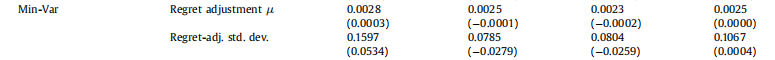

In [37]:
# 汇总
df_all = (pd.concat([panel_a_stats, ret_regret_df,pref_mu_sigma_df, pref_minvar_df],axis=0, ignore_index=False))
df_all

,Mkt-RF,SMB,HML,MOM
Mean Return,0.0726,0.0136,0.0437,0.0659
,(0.0236),(-0.0353),(-0.0052),(0.0169)
Std. Deviation,0.1694,0.093,0.0933,0.1183
,(0.0509),(-0.0255),(-0.0252),(-0.0002)
Skewness,-0.125,-0.7604,0.7828,-1.6382
,(0.3102),(-0.3252),(1.2180),(-1.2030)
Regret adjustment μ,0.0192,-0.0054,0.0012,-0.0036
,(0.0164),(-0.0083),(-0.0016),(-0.0065)
Regret-adj. std. dev.,0.1578,0.1453,0.1289,0.1585
,(0.0102),(-0.0023),(-0.0188),(0.0109)


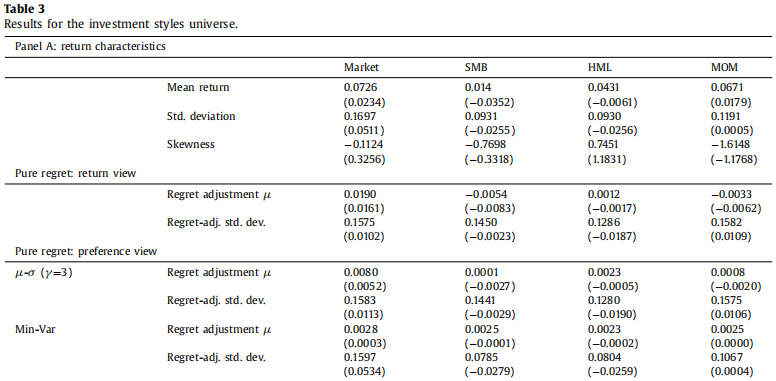

## **Panel B**

In [154]:
gamma = 1.5
def portfolio_optimizer(mu, cov_matrix, method='mu_sigma', gamma=1.5):
    n_assets = len(mu)
    if method == 'mu_sigma':
        objective = lambda w: -(w.dot(mu) - gamma * w.dot(cov_matrix.dot(w)))
    else:  # min_var
        objective = lambda w: w.dot(cov_matrix.dot(w))

    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
    bounds = [(0, 1) for _ in range(n_assets)]
    x0 = np.ones(n_assets) / n_assets
    
    result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-9, 'disp': False})
    
    return result.x if result.success else x0

In [155]:
# 计算年化统计量
def get_annualized_stats(df, assets):
    mu_annual = df[assets].mean() * 252
    cov_annual = df[assets].cov() * 252
    return mu_annual, cov_annual
# 计算权重与均值的偏离
def calculate_deviations(weights):
    return weights - 1.0 / len(weights)

In [156]:
def markowitz_weights(df, assets, gamma=1.5):
    mu, cov = get_annualized_stats(df, assets)
    mu_sigma_w = portfolio_optimizer(mu, cov, 'mu_sigma', gamma)
    min_var_w = portfolio_optimizer(mu, cov, 'min_var')
    
    return (mu_sigma_w, calculate_deviations(mu_sigma_w), min_var_w, calculate_deviations(min_var_w))

In [199]:
def return_regret_weights(df, assets, alpha=1, gamma=1.5):
    mu, cov = get_annualized_stats(df, assets)
    df_temp = df.copy()
    df_temp['R_max'] = df_temp[assets].max(axis=1)
    cov_adjustments = np.array([np.cov(df_temp[asset], df_temp['R_max'])[0, 1] * 252 for asset in assets])
    mu_adjusted = mu + 2 * alpha * gamma * cov_adjustments
    
    # μ-σ优化
    mu_sigma_w = portfolio_optimizer(mu_adjusted, cov, 'mu_sigma', gamma)
    # 最小方差优化（使用调整后的协方差矩阵）
    Z_ret = df_temp[assets].subtract(alpha * df_temp['R_max'], axis=0)
    cov_adjusted = Z_ret.cov() * 252
    min_var_w = portfolio_optimizer(np.zeros(len(assets)), cov_adjusted, 'min_var')
    
    return (mu_sigma_w, calculate_deviations(mu_sigma_w), min_var_w, calculate_deviations(min_var_w))

In [221]:
def preference_minvar(df, assets, alpha=1, gamma_original=1.5, gamma_adjusted=None):
    # 使用日度数据计算，避免年化转换问题
    cov_daily = df[assets].cov()
    n_assets = len(assets)
    ones = np.ones(n_assets)
    inv_cov = np.linalg.inv(cov_daily)
    min_var_w = inv_cov.dot(ones) / ones.dot(inv_cov.dot(ones))
    
    # 计算最小方差组合的日度收益和方差
    df_temp = df.copy()
    df_temp['R_minvar'] = df_temp[assets].dot(min_var_w)
    minvar_var_daily = min_var_w.dot(cov_daily.dot(min_var_w))
    
    # 使用日度方差计算偏好值
    df_temp['pi_minvar'] = df_temp['R_minvar'] - gamma_original * minvar_var_daily
    
    # 计算调整后的日度收益
    Z_pref = df_temp[assets].copy()
    for i, asset in enumerate(assets):
        asset_var_daily = df_temp[asset].var()
        Z_pref[asset] = (df_temp[asset] - alpha * df_temp['pi_minvar'] - alpha * gamma_original * asset_var_daily)
    
    # 计算调整后的日度协方差矩阵并年化
    cov_Z_pref_daily = Z_pref.cov()
    cov_adjusted_daily = alpha * cov_daily + cov_Z_pref_daily
    cov_adjusted = cov_adjusted_daily * 252  # 年化
    
    # 计算调整后的最小方差组合
    inv_cov_adj = np.linalg.inv(cov_adjusted)
    adj_min_var_w = inv_cov_adj.dot(ones) / ones.dot(inv_cov_adj.dot(ones))
    
    return adj_min_var_w, calculate_deviations(adj_min_var_w)

In [220]:
# 修改调用方式
def preference_regret_weights(df, assets, alpha=1, gamma=1.5):
    mu, cov = get_annualized_stats(df, assets)
    variances_daily = df[assets].var()
    pi_values = df[assets].copy()
    
    for i, asset in enumerate(assets):
        pi_values[asset] = df[asset] - gamma * variances_daily[i]
    
    pi_values['pi_max'] = pi_values[assets].max(axis=1)
    
    # 计算调整后的期望收益
    cov_adjustments = np.array([np.cov(df[asset], pi_values['pi_max'])[0, 1] * 252 for asset in assets])
    mu_adjusted = mu + 2 * alpha * gamma * cov_adjustments
    
    # μ-σ优化（使用调整后的风险厌恶系数）
    gamma_adjusted = gamma * (1 + alpha)
    mu_sigma_w = portfolio_optimizer(mu_adjusted, cov, 'mu_sigma', gamma_adjusted)
    # 最小方差优化
    min_var_w, min_var_dev = preference_minvar(df, assets, alpha, gamma_original=gamma, gamma_adjusted=gamma_adjusted)
    
    return (mu_sigma_w, calculate_deviations(mu_sigma_w), min_var_w, min_var_dev)

In [218]:
def create_panel_b_simple(df_assets, assets, alpha=1, gamma=gamma):
    results = {}
    results['markowitz'] = markowitz_weights(df_assets, assets, gamma)
    results['return_regret'] = return_regret_weights(df_assets, assets, alpha, gamma)
    results['pref_regret'] = preference_regret_weights(df_assets, assets, alpha, gamma)
    
    # 创建结果表格
    strategies = [('Markowitz: μ-σ', results['markowitz'][0:2]), ('Markowitz: Min-Var', results['markowitz'][2:4]),
                  ('Pure Regret Return: μ-σ', results['return_regret'][0:2]), ('Pure Regret Return: Min-Var', results['return_regret'][2:4]),
                  ('Pure Regret Preference: μ-σ', results['pref_regret'][0:2]), ('Pure Regret Preference: Min-Var', results['pref_regret'][2:4])]
    
    # 构建数据
    data = {}
    for strategy, (weights, deviations) in strategies:
        for i, asset in enumerate(assets):
            if asset not in data:
                data[asset] = []
            data[asset].extend([f"{weights[i]:.4f}", f"({deviations[i]:.4f})"])
    
    # 创建多级索引
    index_tuples = []
    for strategy, _ in strategies:
        index_tuples.append((strategy, ' '))
        index_tuples.append((strategy, ' '))
    
    multi_index = pd.MultiIndex.from_tuples(index_tuples)
    return pd.DataFrame(data, index=multi_index)

In [219]:
panel_b = create_panel_b_simple(df_assets, assets, alpha=1, gamma=gamma)
panel_b

Mkt-RF        SMB        HML        MOM
Markowitz: μ-σ                       0.3940     0.0000     0.0000     0.6060
                                   (0.1440)  (-0.2500)  (-0.2500)   (0.3560)
Markowitz: Min-Var                   0.1099     0.3380     0.3244     0.2278
                                  (-0.1401)   (0.0880)   (0.0744)  (-0.0222)
Pure Regret Return: μ-σ              0.5485     0.0000     0.0000     0.4515
                                   (0.2985)  (-0.2500)  (-0.2500)   (0.2015)
Pure Regret Return: Min-Var          0.3167     0.1992     0.2932     0.1910
                                   (0.0667)  (-0.0508)   (0.0432)  (-0.0590)
Pure Regret Preference: μ-σ          0.3603     0.0000     0.1958     0.4439
                                   (0.1103)  (-0.2500)  (-0.0542)   (0.1939)
Pure Regret Preference: Min-Var      0.1099     0.3380     0.3244     0.2278
                                  (-0.1401)   (0.0880)   (0.0744)  (-0.0222)

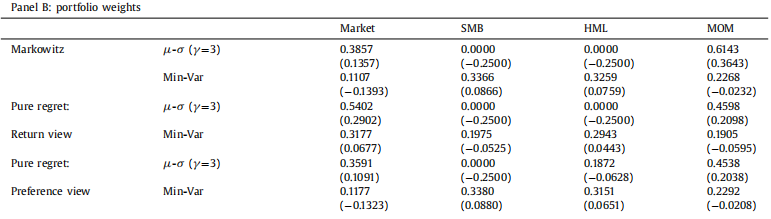